# 02 - Collecting Expert Demonstrations

Behavioural Cloning needs a dataset `D = {(obs, expert_action)}`. We roll the champion out in the 1v1 env and record, for **every** car at **every** step, the observation and the expert's **deterministic (argmax)** action - the target we want the student to reproduce.

**We collect from real games (kickoff starts).** Every episode begins at a normal kickoff and plays out; the orange car *executes* stochastic samples (while still being recorded with its argmax label) so games diverge and we get varied, realistic trajectories. This **narrow, on-task distribution** is deliberate: it is exactly where Behavioural Cloning's *covariate shift* bites (the student drifts off the expert's trajectories at deployment) and therefore where DAgger earns its keep in notebook 04. (Collecting from wildly randomized states instead would broaden the demo distribution and *mask* the covariate-shift problem.) This is the dataset notebook 03 trains on.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # make imitation/ importable -> il_core (cwd = notebooks/)
import il_core
il_core.use_repo_cwd()                       # chdir to repo root so RocketSim finds ./collision_meshes/
import numpy as np
import torch
import matplotlib.pyplot as plt
from il_core import (ExpertPolicy, BCStudent, DemoBuffer, collect_expert_demos,
                     train_bc, rollout_student_relabel, evaluate_student_winrate,
                     save_student_checkpoint, build_env, OBS_DIM, N_ACTIONS,
                     EXPERT_CKPT, DATA_DIR, ARTIFACT_DIR, REPO_ROOT)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(ARTIFACT_DIR, exist_ok=True)
print('engine loaded | OBS_DIM', OBS_DIM, '| N_ACTIONS', N_ACTIONS)

engine loaded | OBS_DIM 107 | N_ACTIONS 90


## Config
`N_EPISODES` is deliberately modest so this runs quickly and barely disturbs the live PPO training sharing the CPU. Scale it up (e.g. 200+) for the final submission numbers when the CPU is free.

In [2]:
N_EPISODES = 60      # scaled up for tighter numbers (bump to 200+ if CPU is fully free)
MAX_SECONDS = 20     # per-episode cap (game seconds)
SEED = 0

In [3]:
expert = ExpertPolicy(device='cpu')
def _p(ep, tot, n): print(f'  episode {ep}/{tot}  |  {n} pairs so far', flush=True)
buf = collect_expert_demos(expert, N_EPISODES, max_seconds=MAX_SECONDS,
                           randomize=False, seed=SEED, progress=_p)  # kickoff games
buf.save(DATA_DIR)
print('\nsaved', len(buf), 'demonstrations to', DATA_DIR)

  episode 1/60  |  486 pairs so far


  episode 2/60  |  1086 pairs so far


  episode 3/60  |  1228 pairs so far


  episode 4/60  |  1366 pairs so far


  episode 5/60  |  1966 pairs so far


...

  episode 57/60  |  24938 pairs so far


  episode 58/60  |  25538 pairs so far


  episode 59/60  |  26138 pairs so far


  episode 60/60  |  26528 pairs so far



saved 26528 demonstrations to C:\Users\Lasca\Desktop\Pro\IE\Courses\REINFORCEMENT LEARNING & AUTONOMOUS SYSTEMS\Group Project\rlgym\imitation\data


## Dataset analysis
Size, action usage, episode returns/lengths, and observation stats.

In [4]:
X, y = buf.observations, buf.actions
print('observations:', X.shape, '| actions:', y.shape)
print('distinct actions used:', len(np.unique(y)), '/', N_ACTIONS)
print('episodes:', len(buf.episode_lengths),
      '| mean length:', round(float(np.mean(buf.episode_lengths)), 1),
      '| mean result:', round(float(np.mean(buf.episode_returns)), 3))

observations: (26528, 107) | actions: (26528,)
distinct actions used: 89 / 90
episodes: 60 | mean length: 221.1 | mean result: 0.517


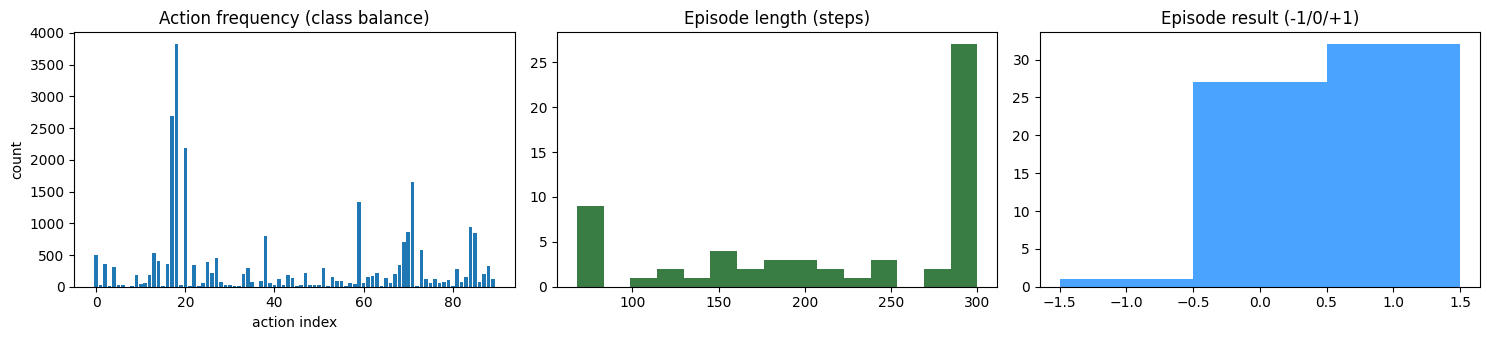

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
counts = np.bincount(y, minlength=N_ACTIONS)
ax[0].bar(range(N_ACTIONS), counts); ax[0].set_title('Action frequency (class balance)')
ax[0].set_xlabel('action index'); ax[0].set_ylabel('count')
ax[1].hist(buf.episode_lengths, bins=15, color='#3a7d44'); ax[1].set_title('Episode length (steps)')
ax[2].hist(buf.episode_returns, bins=[-1.5,-0.5,0.5,1.5], color='#4aa3ff'); ax[2].set_title('Episode result (-1/0/+1)')
plt.tight_layout(); plt.show()

In [6]:
# class imbalance summary -> motivates why top-1 accuracy alone can mislead
frac = counts / counts.sum()
order = np.argsort(frac)[::-1]
print('most common action %4d used %.1f%% of the time' % (order[0], 100*frac[order[0]]))
print('top-5 actions cover %.1f%% of all demonstrations' % (100*frac[order[:5]].sum()))
print('a majority-class baseline would score top-1 acc =', round(float(frac.max()), 3))

most common action   18 used 14.4% of the time
top-5 actions cover 44.0% of all demonstrations
a majority-class baseline would score top-1 acc = 0.144


**Research note (covered in 03).** The action distribution is highly imbalanced - a handful of controls dominate. That sets the bar: a trivial 'always predict the most common action' baseline already gets the accuracy printed above, so the BC student must beat *that* to show it learned the expert's state-dependent behaviour, not just the marginal.